In [1]:
import os
import numpy as np
import pandas as pd


# Load train / validation

data_dir = os.path.join(os.getcwd(), "Data/processed")
train_path = os.path.join(data_dir, "train_data.csv")
val_path   = os.path.join(data_dir, "validation_data.csv")

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Columns:", train_df.columns.tolist())

# Select count-like features for Poisson

# P=10 features:
feature_names = [
    "PTS per 36",
    "REB per 36",
    "AST per 36",
    "Avg minutes",
    "FG% (logit)",
    "3P% (logit)",
    "FT% (logit)",
    "WS/48",
    "BPM",
    "VORP",
]

# Helpers
EPS = 1e-6
def safe_div(a, b):
    return a / np.maximum(b, EPS)

def logit(p):
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))

def make_X_10(df: pd.DataFrame) -> np.ndarray:
    # Required raw columns (based on your CSV columns list)
    # minutes_played, points, total_rebounds, assists are totals
    mp = df["minutes_played"].fillna(0).astype(float).values
    pts = df["points"].fillna(0).astype(float).values
    reb = df["total_rebounds"].fillna(0).astype(float).values
    ast = df["assists"].fillna(0).astype(float).values

    # Convert totals to per-36 rates
    # pts_per36 = points / minutes * 36
    pts36 = safe_div(pts, mp) * 36.0
    reb36 = safe_div(reb, mp) * 36.0
    ast36 = safe_div(ast, mp) * 36.0

    # Avg minutes per game (use games to avoid "total minutes" scaling)
    g = df["games"].fillna(0).astype(float).values
    avg_mp = safe_div(mp, np.maximum(g, 1.0))  # avoid div by 0; if games=0, treat as 0-ish

    # Percentages -> logit
    fg_logit = logit(df["field_goal_percentage"].astype(float).values)
    tp_logit = logit(df["3_point_percentage"].astype(float).values)
    ft_logit = logit(df["free_throw_percentage"].astype(float).values)

    # Advanced metrics (continuous)
    ws48 = df["win_shares_per_48_minutes"].astype(float).values
    bpm  = df["box_plus_minus"].astype(float).values
    vorp = df["value_over_replacement"].astype(float).values

    X = np.column_stack([pts36, reb36, ast36, avg_mp, fg_logit, tp_logit, ft_logit, ws48, bpm, vorp])
    return X

# Sanity check required columns exist
required_cols = [
    "games", "minutes_played", "points", "total_rebounds", "assists",
    "field_goal_percentage", "3_point_percentage", "free_throw_percentage",
    "win_shares_per_48_minutes", "box_plus_minus", "value_over_replacement"
]
for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Column {col} not found in train_data.csv")
    if col not in val_df.columns:
        raise ValueError(f"Column {col} not found in validation_data.csv")

# Build X_train / X_val with P=10 (keep same variable names downstream expects)
X_train = make_X_10(train_df)  # (N_train, 10)
X_val   = make_X_10(val_df)    # (N_val, 10)


N_train, P = X_train.shape
N_val, _   = X_val.shape
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Concatenate train + val for one model
#    (so the NumPyro plates have fixed size)
X_all = np.concatenate([X_train, X_val], axis=0)  # (N_total, P)
N_total = X_all.shape[0]
split_idx = N_train  # first N_train rows are training players
print("X_all shape:", X_all.shape)

# standardize features for better optimization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
X_train_scaled = X_all_scaled[:N_train]
X_val_scaled = X_all_scaled[N_train:]


Train shape: (1616, 24)
Val shape: (53, 24)
Columns: ['id', 'year', 'rank', 'overall_pick', 'team', 'player', 'college', 'years_active', 'games', 'minutes_played', 'points', 'total_rebounds', 'assists', 'field_goal_percentage', '3_point_percentage', 'free_throw_percentage', 'average_minutes_played', 'points_per_game', 'average_total_rebounds', 'average_assists', 'win_shares', 'win_shares_per_48_minutes', 'box_plus_minus', 'value_over_replacement']
X_train shape: (1616, 10)
X_val shape: (53, 10)
X_all shape: (1669, 10)


**CV_Tuning_MSE** & **Training**

In [28]:
import numpy as np
import jax.numpy as jnp

from Train import (
    cross_validate_on_train,
    fit_style_model,
    build_design_matrix,
)
from Model import StyleModelConfig
from Metrics import run_ppc_suite, null_column_permutation, run_null_suite


# 
def log_uniform(rng, low, high, size=None):
    """sample 10**U(low, high)"""
    u = rng.uniform(low, high, size=size)
    return 10 ** u

def make_candidate_configs(
    K_list=(3, 5, 7),
    n_per_K=12,
    base_alpha=0.5,
    seed=0,
):
    
    rng = np.random.default_rng(seed)
    cfgs = []

    for K in K_list:
        for _ in range(n_per_K):
            # log10 in [-1, 1]  => [0.1, 10]
            tau_beta = float(log_uniform(rng, -1.0, 1.0))
            tau_sigma = float(log_uniform(rng, -1.0, 1.0))

            # multiplier：log10 in [-0.7, 0.7] => ~[0.2, 5]
            tb_count = float(log_uniform(rng, -0.7, 0.7))
            tb_pct   = float(log_uniform(rng, -0.7, 0.7))
            tb_other = float(log_uniform(rng, -0.7, 0.7))

            cfgs.append(
                StyleModelConfig(
                    K=K,
                    alpha=base_alpha,
                    alpha_w=jnp.asarray(np.linspace(0.7, 1.3, K) / np.mean(np.linspace(0.7, 1.3, K))),
                    tau_beta=tau_beta,
                    tau_sigma=tau_sigma,
                    tau_beta_count=tb_count,
                    tau_beta_pct=tb_pct,
                    tau_beta_other=tb_other,
                )
            )
    return cfgs


def rank_by_ari_then_mse(cv_results):
    def key(r):
        ari = r.extra_metrics.get("ari_stability", float("-inf"))
        return (-ari, r.mean_mse)
    return sorted(cv_results, key=key)

def print_cv_table(cv_results, top=10, title=""):
    ranked = rank_by_ari_then_mse(cv_results)
    if title:
        print("\n" + title)
    for r in ranked[:top]:
        ari = r.extra_metrics.get("ari_stability", float("nan"))
        print(
            f"K={r.config.K:2d} alpha={r.config.alpha:.3g} "
            f"tau_beta={r.config.tau_beta:.3g} tau_sigma={r.config.tau_sigma:.3g} | "
            f"MSE={r.mean_mse:.4f}±{r.std_mse:.4f} | ARI={ari:.4f}"
        )
    return ranked


def ppc_score_from_suite(ppc_out):
    p = ppc_out["p"]
    vecs = []

    # moments: dict of arrays (P,)
    for k, v in p["moments"].items():
        vecs.append(np.asarray(v).ravel())

    # corr_upper: (P*(P-1)/2,)
    vecs.append(np.asarray(p["corr_upper"]).ravel())

    # mse_feat: (P,)
    vecs.append(np.asarray(p["mse_feat"]).ravel())

    if "unique_ratio" in p:
        vecs.append(np.asarray(p["unique_ratio"]).ravel())

    all_p = np.concatenate(vecs)
    return float(np.mean(np.abs(all_p - 0.5)))

def ppn_separation_from_null(ppc_out, null_out):
    pm = ppc_out["p"]
    pn = null_out["p"]
    vec_m, vec_n = [], []

    # moments
    for k in pm["moments"].keys():
        vec_m.append(np.asarray(pm["moments"][k]).ravel())
        vec_n.append(np.asarray(pn["moments"][k]).ravel())

    # corr_upper
    vec_m.append(np.asarray(pm["corr_upper"]).ravel())
    vec_n.append(np.asarray(pn["corr_upper"]).ravel())

    # unique_ratio
    if "unique_ratio" in pm and "unique_ratio" in pn:
        vec_m.append(np.asarray(pm["unique_ratio"]).ravel())
        vec_n.append(np.asarray(pn["unique_ratio"]).ravel())

    m = np.concatenate(vec_m)
    n = np.concatenate(vec_n)
    return float(np.mean(np.abs(m - n)))

def stage2_ppc_ppn_screen(
    train_df,
    configs,
    num_steps=600,
    seed=123,
    n_rep=80,
    keep_frac=0.5,
):
    X_train_std, stats_train = build_design_matrix(train_df, stats=None)

    scored = []
    for i, cfg in enumerate(configs):
        out = fit_style_model(
            X_train_std,
            config=cfg,
            num_steps=num_steps,
            rng_seed=seed + i,
            log_every=max(1, num_steps // 3),
        )
        theta = np.array(out["theta"])
        beta  = np.array(out["beta"])
        sigma = np.array(out["sigma"])

        ppc_out = run_ppc_suite(
            X_obs=X_train_std,
            theta=theta,
            beta=beta,
            sigma=sigma,
            n_rep=n_rep,
            seed=seed + i,
            compute_unique=True,
            unique_decimals=2,
        )
        ppc_score = ppc_score_from_suite(ppc_out)

        null_reps = null_column_permutation(X_train_std, n_rep=n_rep, seed=seed + i)
        null_out = run_null_suite(X_train_std, null_reps, unique_decimals=2)
        sep = ppn_separation_from_null(ppc_out, null_out)

        scored.append((cfg, ppc_score, sep))

    scored.sort(key=lambda t: (-t[2], t[1]))

    keep = max(1, int(len(scored) * keep_frac))
    kept = scored[:keep]

    print("\n[Stage-2] PPC/PPN screening results (top kept):")
    for cfg, ppc_s, sep in kept[:min(10, len(kept))]:
        print(
            f"K={cfg.K:2d} tau_beta={cfg.tau_beta:.3g} tau_sigma={cfg.tau_sigma:.3g} | "
            f"PPCscore={ppc_s:.3f} (low good) | PPNsep={sep:.3f} (high good)"
        )

    return [t[0] for t in kept], scored


# -------- Stage-0: generate a large candidate pool --------
candidate_configs = make_candidate_configs(
    K_list=(3, 5, 7),
    n_per_K=10,     
    base_alpha=0.5,
    seed=0,
)

# -------- Stage-1: cheap CV (short steps) --------
cv_stage1 = cross_validate_on_train(
    train_df,
    candidate_configs=candidate_configs,
    n_splits=3,
    num_steps=400,   # cheap
    base_seed=42,
)
ranked1 = print_cv_table(cv_stage1, top=10, title="[Stage-1] Cheap CV (sorted by ARI then MSE)")

topM = 12
configs_s2 = [r.config for r in ranked1[:topM]]

# -------- Stage-2: PPC/PPN screening on full train (short fit) --------
configs_s3, stage2_scored = stage2_ppc_ppn_screen(
    train_df=train_df,
    configs=configs_s2,
    num_steps=600,
    seed=100,
    n_rep=80,
    keep_frac=0.5,   # 保留一半
)

# -------- Stage-3: expensive CV (longer steps) --------
cv_stage3 = cross_validate_on_train(
    train_df,
    candidate_configs=configs_s3,
    n_splits=3,
    num_steps=1500,  # expensive
    base_seed=42,
)
ranked3 = print_cv_table(cv_stage3, top=len(cv_stage3), title="[Stage-3] Final CV (sorted by ARI then MSE)")

best = ranked3[0]
print(
    f"\n[SELECTED] Best config: K={best.config.K}, alpha={best.config.alpha}, "
    f"tau_beta={best.config.tau_beta:.3g}, tau_sigma={best.config.tau_sigma:.3g} | "
    f"MSE={best.mean_mse:.4f} | ARI={best.extra_metrics.get('ari_stability', float('nan')):.4f}"
)



[CV] Evaluating config 1/30: StyleModelConfig(K=3, alpha=0.5, alpha_w=Array([0.7, 1. , 1.3], dtype=float32), tau_beta=1.8789852661499484, tau_sigma=0.3463964459891802, tau_beta_count=0.22769994908826544, tau_beta_pct=0.2104450378024628, tau_beta_other=2.7452274629901714)
[CV]  Fold 1/3
[TRAIN] step=100, loss=54071.516
[TRAIN] step=200, loss=43464.844
[TRAIN] step=300, loss=39416.258
[TRAIN] step=400, loss=36350.832
[CV]    Fold 1 MSE = 1.0560
[CV]  Fold 2/3
[TRAIN] step=100, loss=71561.000
[TRAIN] step=200, loss=55207.199
[TRAIN] step=300, loss=53471.152
[TRAIN] step=400, loss=45666.656
[CV]    Fold 2 MSE = 1.3513
[CV]  Fold 3/3
[TRAIN] step=100, loss=171321.078
[TRAIN] step=200, loss=119977.375
[TRAIN] step=300, loss=105167.289
[TRAIN] step=400, loss=76020.516
[CV]    Fold 3 MSE = 1.0687
[CV] Config StyleModelConfig(K=3, alpha=0.5, alpha_w=Array([0.7, 1. , 1.3], dtype=float32), tau_beta=1.8789852661499484, tau_sigma=0.3463964459891802, tau_beta_count=0.22769994908826544, tau_beta_pct

In [ ]:
from Train import cross_validate_on_train
from Model import StyleModelConfig


# candidate_configs = [
#     StyleModelConfig(K=3, alpha=0.5, tau_beta=1.0, tau_sigma=1.0),
#     StyleModelConfig(K=5, alpha=0.5, tau_beta=1.0, tau_sigma=1.0),
#     StyleModelConfig(K=7, alpha=0.5, tau_beta=1.0, tau_sigma=1.0),
# ]

# # -----------------------------------------------------------------
# # Cross-validation on train_data (validation_data is untouched here)
# # -----------------------------------------------------------------
# cv_results = cross_validate_on_train(
#     train_df,
#     candidate_configs=candidate_configs,
#     n_splits=3,      # small N in this dataset; you can change to 5 if larger
#     num_steps=1500,  # fewer steps for CV runs
#     base_seed=42,
# )

# # Pick best config by lowest mean MSE
# best = min(cv_results, key=lambda r: r.mean_mse)
# print("\n[CV] Summary of configs:")
# for r in cv_results:
#     print(
#         f"  Config K={r.config.K}, alpha={r.config.alpha}: "
#         f"mean MSE={r.mean_mse:.4f} ± {r.std_mse:.4f}"
#     )

# print(
#     f"\n[CV] Best config: K={best.config.K}, "
#     f"alpha={best.config.alpha}, MSE={best.mean_mse:.4f}"
# )

# -----------------------------------------------------------------
# Train final model on full train_data, evaluate on validation_data
# -----------------------------------------------------------------

from Train import fit_style_model
best_config_assumed = StyleModelConfig(K=5, alpha=0.5, tau_beta=8.21, tau_sigma=0.198)

try:
    best
    best_config = best.config
except NameError:
    best_config = best_config_assumed

posterior_all = fit_style_model(
    X_all_scaled,
    config=best_config,
    num_steps=4000,
    rng_seed=123,
)

loss_trace  = posterior_all["loss_trace"]
theta = posterior_all["theta"]
beta        = posterior_all["beta"]
sigma       = posterior_all["sigma"]



[TRAIN] step=500, loss=55492.234
[TRAIN] step=1000, loss=41648.820
[TRAIN] step=1500, loss=35615.438
[TRAIN] step=2000, loss=32069.066
[TRAIN] step=2500, loss=28525.461
[TRAIN] step=3000, loss=26782.881
[TRAIN] step=3500, loss=25978.650
[TRAIN] step=4000, loss=24932.500


In [30]:
# check points
print("X_all_scaled shape:", X_all_scaled.shape)   # should be (N, P=10)
print("theta shape:", np.array(theta).shape)       # (N, K=7)
print("beta shape:", np.array(beta).shape)         # (K=7, P=10)

# save posterior samples for later analysis
posterior_samples_path = os.path.join(data_dir, "posterior_samples.pkl")
posterior_to_save = {
    "theta": posterior_all["theta"],     # np.array / jnp.array
    "beta": posterior_all["beta"],       # np.array / jnp.array
    "sigma": posterior_all["sigma"],     # np.array / jnp.array
    "loss_trace": posterior_all["loss_trace"], # list of floats
}

import pickle
with open(posterior_samples_path, "wb") as f:
    pickle.dump(posterior_to_save, f)


X_all_scaled shape: (1669, 10)
theta shape: (1669, 5)
beta shape: (5, 10)


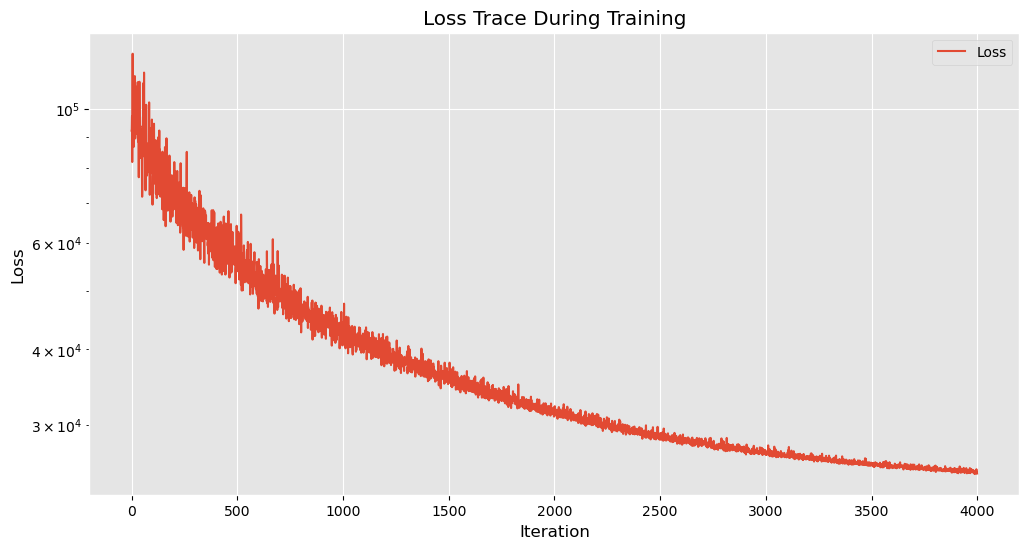

In [31]:
# Plot loss trace
import matplotlib.pyplot as plt
plt.style.use("ggplot")
# black color for titles, label strings
plt.rcParams.update({'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black', 'ytick.color': 'black'})
plt.figure(figsize=(12, 6))
plt.plot(loss_trace, label="Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Loss Trace During Training")
plt.legend()
plt.show()

[Shapes] X_obs: (1616, 10), X_pred: (1669, 10), theta: (1669, 5), beta: (5, 10)
[Obs finite rows] bad rows in X_obs (NaN/Inf): 0 / 1616
[Obs NaN/Inf per feature] top issues:
[Align A] Using n=1616. X_obs_aligned=(1616, 10), X_pred_aligned=(1616, 10)


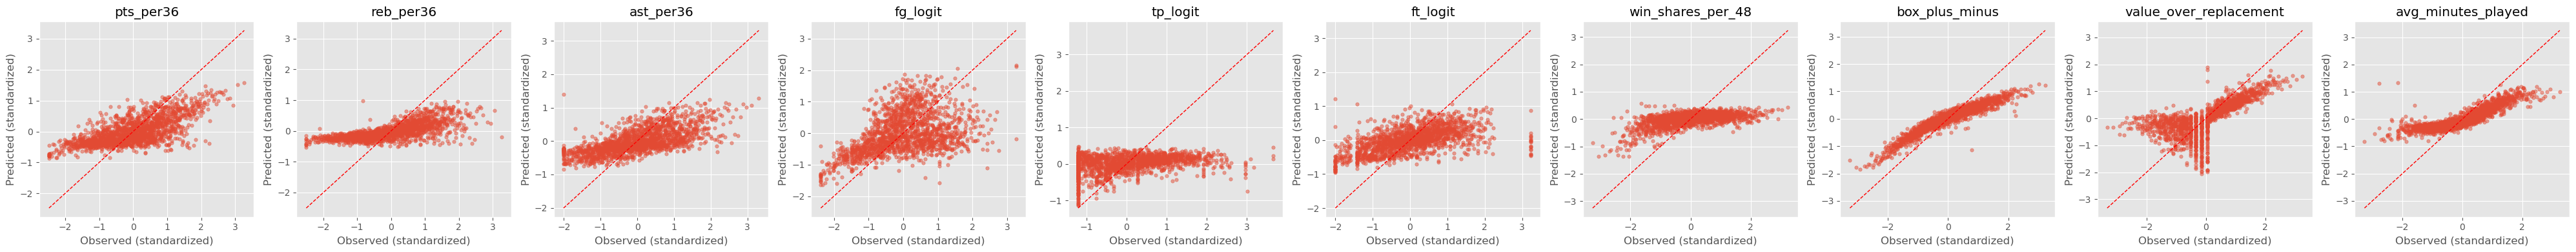

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 0) Fetch theta/beta
# ----------------------------
if "posterior_all" in globals() and isinstance(posterior_all, dict):
    theta_train = np.asarray(posterior_all.get("theta"))
    beta = np.asarray(posterior_all.get("beta"))

if "theta_train" not in globals() or "beta" not in globals():
    raise NameError("Missing theta_train/beta. Run training first to produce them.")

# ----------------------------
# 1) Fetch X (observed) + feature names
# ----------------------------
if "X_train_std" in globals():
    X_obs = np.asarray(X_train_std)
elif "X_all_scaled" in globals():
    X_obs = np.asarray(X_all_scaled)
else:
    raise NameError("Missing X_train_std (or X_all_scaled). Build the standardized design matrix first.")

if "stats_train" in globals() and hasattr(stats_train, "feature_names"):
    feature_names = list(stats_train.feature_names)
else:
    feature_names = [f"feat_{i}" for i in range(X_obs.shape[1])]

theta_train = np.asarray(theta_train)
beta = np.asarray(beta)

# theta can be (N,K) or (S,N,K)
if theta_train.ndim == 3:
    theta_point = theta_train.mean(axis=0)   # (N,K)
elif theta_train.ndim == 2:
    theta_point = theta_train                # (N,K)
else:
    raise ValueError(f"Unexpected theta_train shape: {theta_train.shape}. Expected (N,K) or (S,N,K).")

X_pred = theta_point @ beta  # (N_pred, P)

N_obs, P_obs = X_obs.shape
N_pred, P_pred = X_pred.shape

print(f"[Shapes] X_obs: {X_obs.shape}, X_pred: {X_pred.shape}, theta: {theta_point.shape}, beta: {beta.shape}")

if P_obs != P_pred:
    raise ValueError(f"Feature dimension mismatch: X_obs P={P_obs} vs X_pred P={P_pred}.")

# ----------------------------
# 2) Diagnose why X_obs has fewer rows (typical: NaN/Inf filtering)
# ----------------------------
finite_row_mask_obs = np.isfinite(X_obs).all(axis=1)
num_bad_rows_obs = (~finite_row_mask_obs).sum()
print(f"[Obs finite rows] bad rows in X_obs (NaN/Inf): {num_bad_rows_obs} / {N_obs}")

# Per-column diagnostics (optional but often very informative)
bad_per_col = np.sum(~np.isfinite(X_obs), axis=0)
top_bad = sorted([(feature_names[i], int(bad_per_col[i])) for i in range(P_obs)], key=lambda x: -x[1])[:10]
print("[Obs NaN/Inf per feature] top issues:")
for name, cnt in top_bad:
    if cnt > 0:
        print(f"  {name:25s}  {cnt}")

# ----------------------------
# 3) Align rows (choose robust strategy)
# ----------------------------
# We do NOT have row IDs here, so we cannot perfectly map 1616 obs rows back to the 1669 theta rows.
# The only principled alignment is: rebuild X using the exact same filtered dataframe used in training.
# However, to move forward for plotting/debugging, we provide safe fallbacks.

# ---- Strategy A (recommended for plotting/debugging): trim both to the same N by index,
#      but only after ensuring X_obs is finite row-wise.
#      This assumes X_obs corresponds to the first N_obs rows of the training order (often true).
use_strategy = "A"  # "A" or "B"

if use_strategy == "A":
    # Make X_obs row-wise finite first (in case your X_obs still contains NaN/Inf rows)
    X_obs_clean = X_obs[finite_row_mask_obs]
    # If cleaning changed N, report it
    if X_obs_clean.shape[0] != N_obs:
        print(f"[Cleaned] X_obs -> {X_obs_clean.shape} after dropping NaN/Inf rows")
    # Now align by truncating to common prefix length
    n = min(X_obs_clean.shape[0], N_pred)
    X_obs_aligned = X_obs_clean[:n]
    X_pred_aligned = X_pred[:n]
    print(f"[Align A] Using n={n}. X_obs_aligned={X_obs_aligned.shape}, X_pred_aligned={X_pred_aligned.shape}")

elif use_strategy == "B":
    # Emergency: just truncate raw arrays (no cleaning)
    n = min(N_obs, N_pred)
    X_obs_aligned = X_obs[:n]
    X_pred_aligned = X_pred[:n]
    print(f"[Align B] Using n={n}. X_obs_aligned={X_obs_aligned.shape}, X_pred_aligned={X_pred_aligned.shape}")

else:
    raise ValueError("use_strategy must be 'A' or 'B'.")

# ----------------------------
# 4) Plot scatter panels
# ----------------------------
P = P_obs
plt.style.use("ggplot")
fig, axes = plt.subplots(1, P, figsize=(4 * P, 4), squeeze=False)
axes = axes.ravel()

for i in range(P):
    ax = axes[i]
    x = np.asarray(X_obs_aligned[:, i]).ravel()
    y = np.asarray(X_pred_aligned[:, i]).ravel()

    # synchronize finite mask per feature (extra safety)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    ax.scatter(x, y, alpha=0.5, s=15)
    if x.size > 0 and y.size > 0:
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)

    ax.set_title(feature_names[i] if i < len(feature_names) else f"feat_{i}")
    ax.set_xlabel("Observed (standardized)")
    ax.set_ylabel("Predicted (standardized)")

plt.tight_layout()
plt.show()


**Posterior Predictive Check**

In [36]:
# reload posterior samples from disk
import pickle
import os

data_dir = os.path.join(os.getcwd(), "Data/processed")
posterior_samples_path = os.path.join(data_dir, "posterior_samples.pkl")
with open(posterior_samples_path, "rb") as f:
    posterior_samples = pickle.load(f)

# load params that we need
theta = posterior_samples["theta"]
beta = posterior_samples["beta"]
sigma = posterior_samples["sigma"]

posterior_all = {
    "theta": theta,
    "beta": beta,
    "sigma": sigma,
}

In [37]:
from Checking import run_full_checks
from Train import infer_theta_given_beta
from Train import build_design_matrix

X_all_std, stats_all = build_design_matrix(
    pd.concat([train_df, val_df], axis=0).reset_index(drop=True),
    stats=None,
)
X_train_std = X_all_std[:N_train]
X_val_std = X_all_std[N_train:]

report = run_full_checks(
    X_train_std=X_train_std,
    X_val_std=X_val_std,
    posterior_all=posterior_all,
    infer_theta_given_beta_fn=infer_theta_given_beta,
    stats_train=stats_all,
    n_rep=200,
    seed=0,
)
print(report["summary"])
report["summary"]

{'train_ppc': {'moments': {'mean': {'median_p': 0.0, 'frac_extreme': 0.7}, 'var': {'median_p': 0.015, 'frac_extreme': 0.6}, 'skew': {'median_p': 0.07, 'frac_extreme': 0.4}, 'kurt': {'median_p': 0.045, 'frac_extreme': 0.5}}, 'corr_upper': {'median_p': 0.0, 'frac_extreme': 0.8888888888888888}, 'quantiles': {'q05': {'median_p': 0.005, 'frac_extreme': 0.9}, 'q50': {'median_p': 0.005, 'frac_extreme': 0.8}, 'q95': {'median_p': 0.18, 'frac_extreme': 0.3}}, 'tail_prob': {'median_p': 0.305, 'frac_extreme': 0.4}, 'tail_prob_worst_features': [5, 8, 4, 1, 2], 'unique_ratio': {'median_p': 0.0, 'frac_extreme': 0.8}, 'unique_ratio_worst_features': [0, 3, 5, 4, 6], 'theta_entropy': {'median_p': 1.0, 'frac_extreme': 1.0}, 'theta_keff': {'median_p': 1.0, 'frac_extreme': 1.0}, 'theta_max': {'median_p': 1.0, 'frac_extreme': 1.0}, 'prototype_cosine_mean': -0.20421870052814484, 'prototype_cosine_max': 0.6091986894607544, 'style_cond_mean_l2_mean': 3.567759704589844, 'style_cond_tail_gap_l1_mean': 0.14856129

{'train_ppc': {'moments': {'mean': {'median_p': 0.0, 'frac_extreme': 0.7},
   'var': {'median_p': 0.015, 'frac_extreme': 0.6},
   'skew': {'median_p': 0.07, 'frac_extreme': 0.4},
   'kurt': {'median_p': 0.045, 'frac_extreme': 0.5}},
  'corr_upper': {'median_p': 0.0, 'frac_extreme': 0.8888888888888888},
  'quantiles': {'q05': {'median_p': 0.005, 'frac_extreme': 0.9},
   'q50': {'median_p': 0.005, 'frac_extreme': 0.8},
   'q95': {'median_p': 0.18, 'frac_extreme': 0.3}},
  'tail_prob': {'median_p': 0.305, 'frac_extreme': 0.4},
  'tail_prob_worst_features': [5, 8, 4, 1, 2],
  'unique_ratio': {'median_p': 0.0, 'frac_extreme': 0.8},
  'unique_ratio_worst_features': [0, 3, 5, 4, 6],
  'theta_entropy': {'median_p': 1.0, 'frac_extreme': 1.0},
  'theta_keff': {'median_p': 1.0, 'frac_extreme': 1.0},
  'theta_max': {'median_p': 1.0, 'frac_extreme': 1.0},
  'prototype_cosine_mean': -0.20421870052814484,
  'prototype_cosine_max': 0.6091986894607544,
  'style_cond_mean_l2_mean': 3.567759704589844,
  

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ppc_1d(rep, obs, p, name="", feature_name=None):
    plt.style.use("ggplot")
    # black color for titles, label strings
    plt.rcParams.update({'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black', 'ytick.color': 'black'})
    plt.figure(figsize=(4, 3))

    plt.hist(rep, bins=30, density=True, alpha=0.6, color="gray")
    plt.axvline(obs, color="black", linewidth=2, label="Observed")

    ql, qr = np.quantile(rep, [0.05, 0.95])
    plt.axvline(ql, color="red", linestyle="--", linewidth=1)
    plt.axvline(qr, color="red", linestyle="--", linewidth=1, label="5%–95%")

    title = name
    if feature_name is not None:
        title += f" | {feature_name}"
    plt.title(title)
    plt.xlabel("Statistic value")
    plt.ylabel("Density")
    plt.legend()
    plt.text(0.02, 0.95, f"p = {p:.3f}", transform=plt.gca().transAxes, va="top")

    plt.tight_layout()
    plt.show()


In [39]:
report

{'meta': {'n_rep': 200,
  'seed': 0,
  'unique_decimals': 2,
  'style_tau': 0.7,
  'feature_names': ['pts_per36',
   'reb_per36',
   'ast_per36',
   'fg_logit',
   'tp_logit',
   'ft_logit',
   'win_shares_per_48',
   'box_plus_minus',
   'value_over_replacement',
   'avg_minutes_played']},
 'train': {'theta_gen_shape': [1616, 5],
  'ppc': {'obs': {'moments': {'mean': array([-1.6878607e-03,  2.7274897e-05, -1.5548778e-03, -2.2800532e-04,
            -3.3126581e-03,  3.3374093e-03,  6.9073793e-03,  7.7068736e-03,
             7.1728234e-03,  5.9816949e-03], dtype=float32),
     'var': array([0.99675506, 0.9958175 , 1.0054402 , 0.98174465, 1.0028629 ,
            0.9919928 , 0.99344516, 0.9967693 , 1.024773  , 0.9910341 ],
           dtype=float32),
     'skew': array([ 0.06126941,  0.03091982,  0.13644426,  0.04346328,  0.6291876 ,
             0.2934693 , -0.00634292, -0.02726396, -0.0777882 ,  0.02311663],
           dtype=float32),
     'kurt': array([2.8391767, 2.797822 , 2.692837 ,

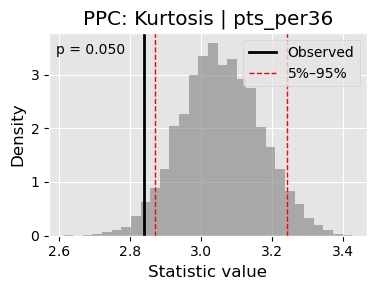

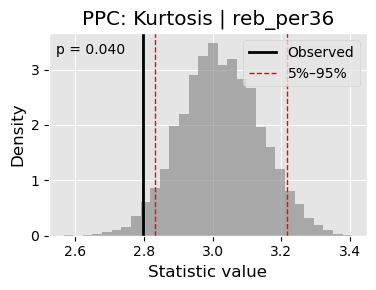

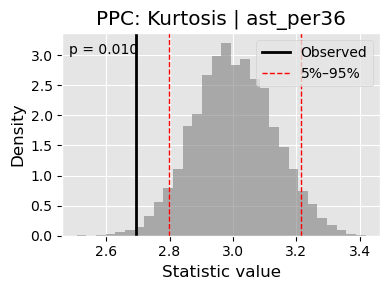

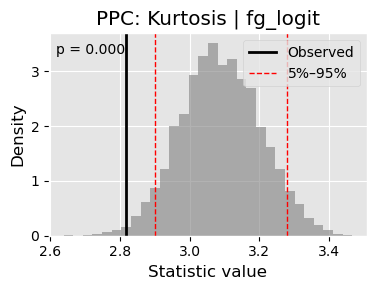

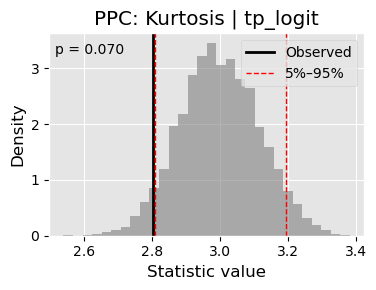

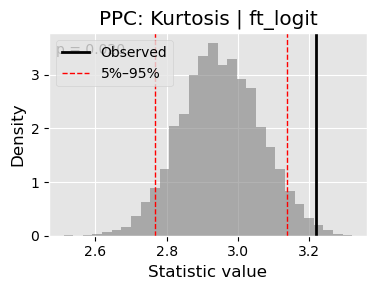

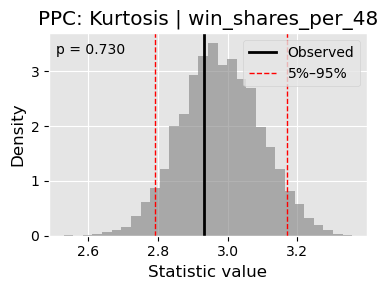

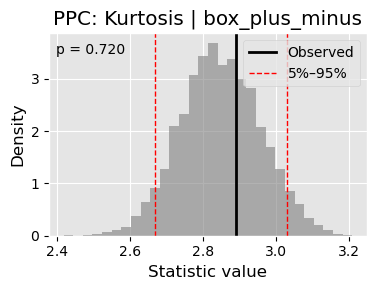

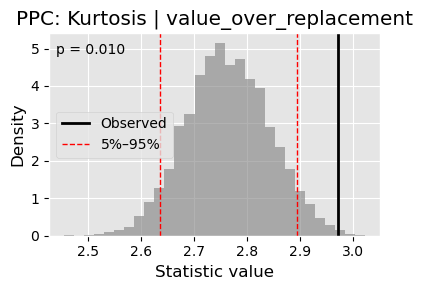

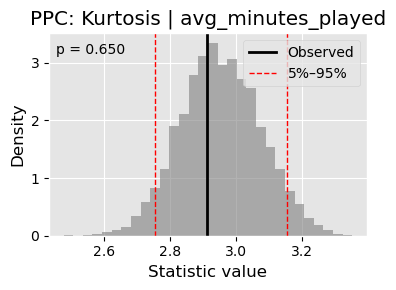

In [40]:
def make_rep_from_mean_sd(rep_mean, rep_sd, n_draw=5000, seed=0):
    rng = np.random.default_rng(seed)
    rep = rng.normal(loc=rep_mean, scale=rep_sd, size=n_draw)
    return rep
notes = report["train"]["ppc"]

obs_all = notes["obs"]["moments"]["kurt"]
rep_mean_all = notes["rep"]["moments_mean"]["kurt"]
rep_sd_all = notes["rep"]["moments_sd"]["kurt"]
p_all = notes["p"]["moments"]["kurt"]

feature_names = report["meta"]["feature_names"]

for j in range(len(obs_all)):
    rep = make_rep_from_mean_sd(
        rep_mean=float(rep_mean_all[j]),
        rep_sd=float(rep_sd_all[j]),
        n_draw=5000,
        seed=0,
    )

    plot_ppc_1d(
        rep=rep,
        obs=float(obs_all[j]),
        p=float(p_all[j]),
        name="PPC: Kurtosis",
        feature_name=feature_names[j],
    )



[-1.6878607e-03  2.7274897e-05 -1.5548778e-03 -2.2800532e-04
 -3.3126581e-03  3.3374093e-03  6.9073793e-03  7.7068736e-03
  7.1728234e-03  5.9816949e-03]
Standard Deviation PPC Plots


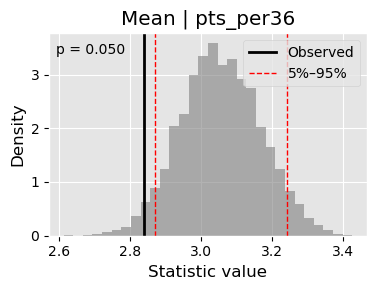

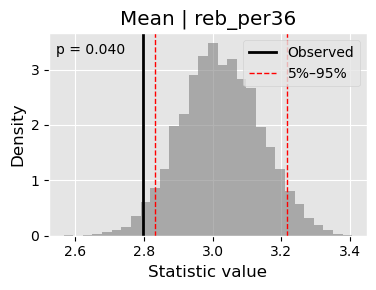

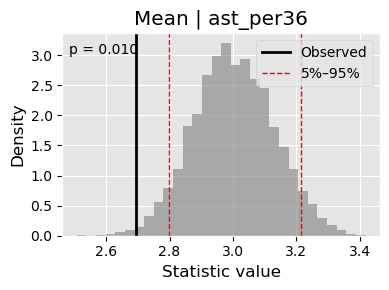

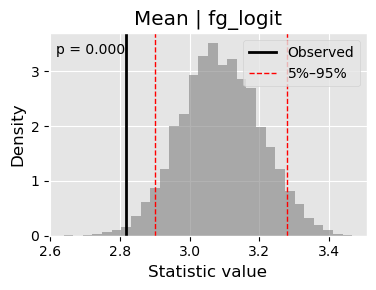

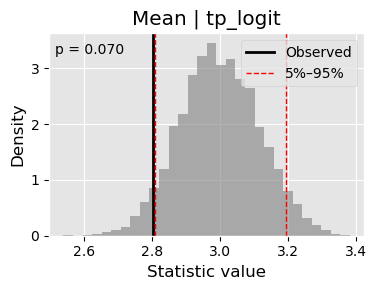

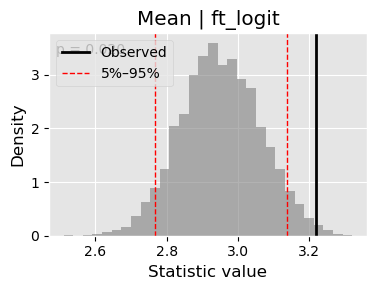

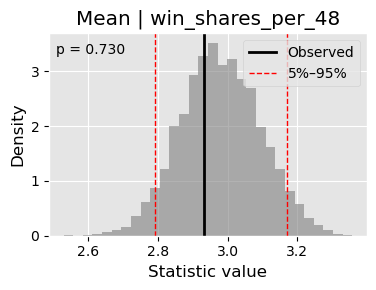

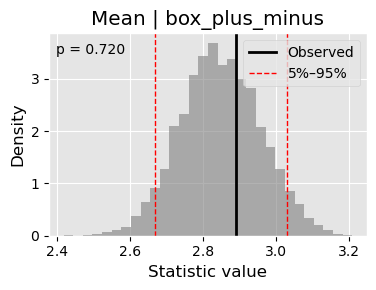

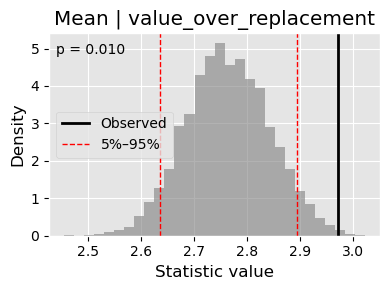

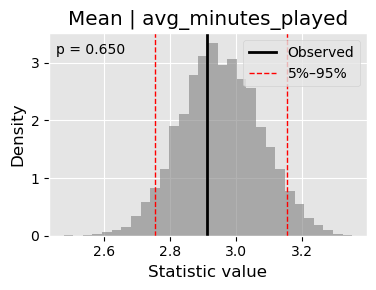

In [41]:
# standard deviation
print(notes["obs"]["moments"]["mean"])

print("Standard Deviation PPC Plots")
for j in range(len(obs_all)):
    rep = make_rep_from_mean_sd(
        rep_mean=float(rep_mean_all[j]),
        rep_sd=float(rep_sd_all[j]),
        n_draw=5000,
        seed=0,
    )

    plot_ppc_1d(
        rep=rep,
        obs=float(obs_all[j]),
        p=float(p_all[j]),
        name="Mean",
        feature_name=feature_names[j],
    )

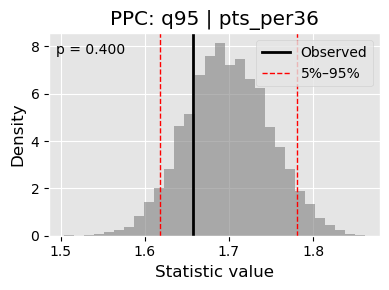

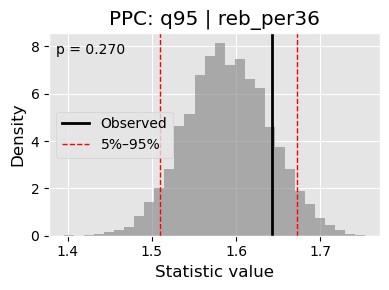

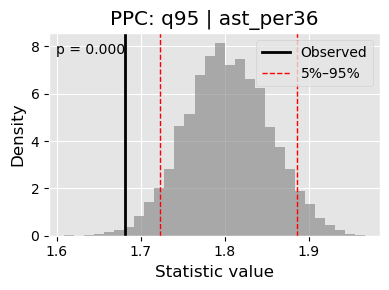

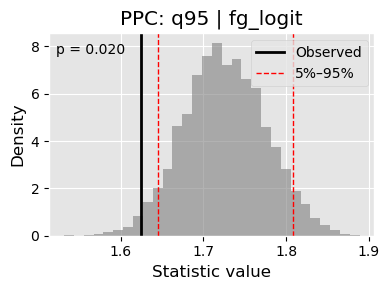

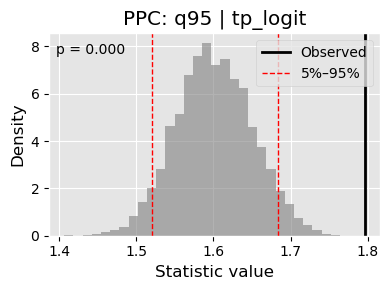

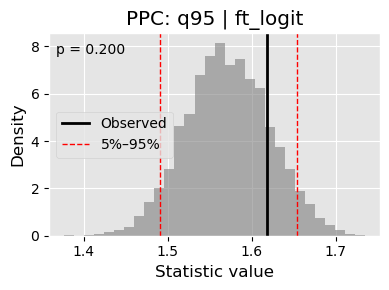

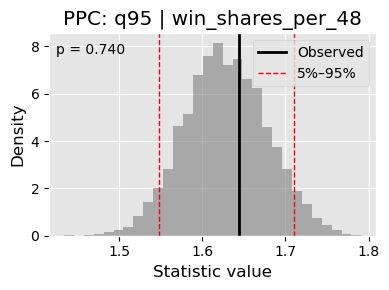

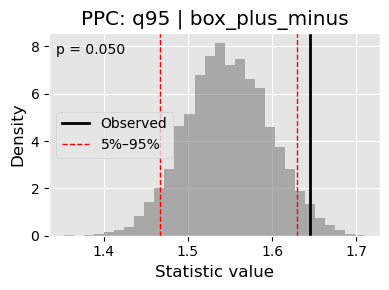

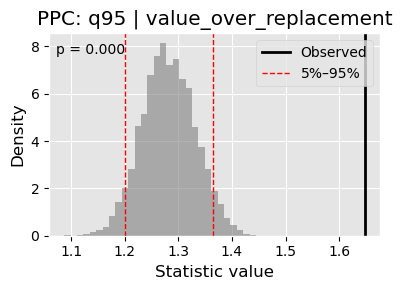

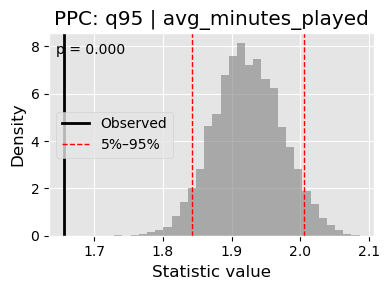

In [12]:
obs_all = notes["obs"]["quantiles"]["q95"]
rep_mean_all = notes["rep"]["quantiles_mean"]["q95"]
p_all = notes["p"]["quantiles"]["q95"]

# simple, robust sd approximation (avoid 0)
rep_sd_all = 0.05 * np.ones_like(rep_mean_all)

for j in range(len(obs_all)):
    rep = make_rep_from_mean_sd(
        rep_mean=float(rep_mean_all[j]),
        rep_sd=float(rep_sd_all[j]),
        n_draw=5000,
    )

    plot_ppc_1d(
        rep=rep,
        obs=float(obs_all[j]),
        p=float(p_all[j]),
        name="PPC: q95",
        feature_name=feature_names[j],
    )


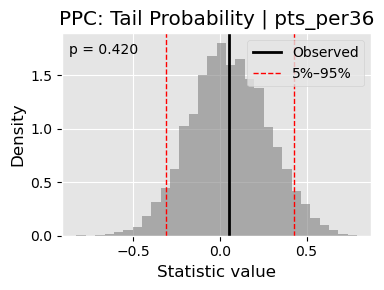

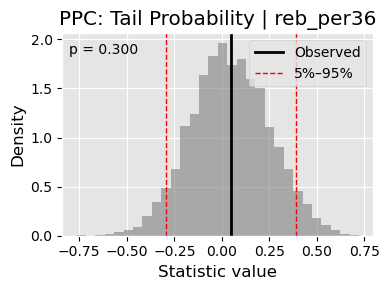

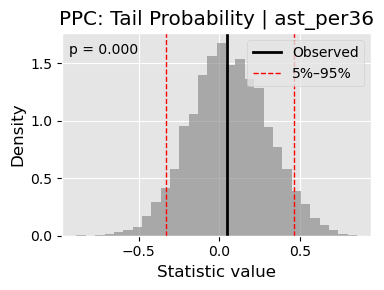

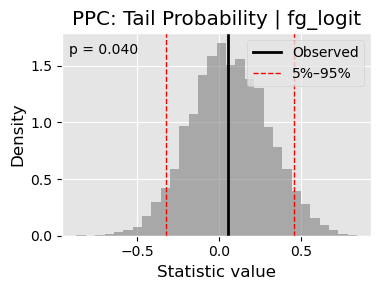

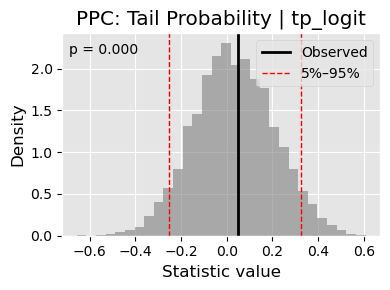

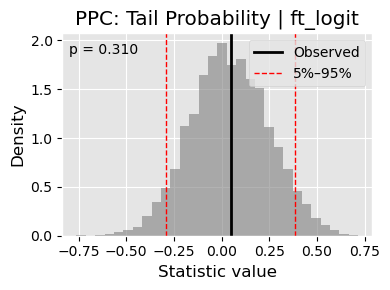

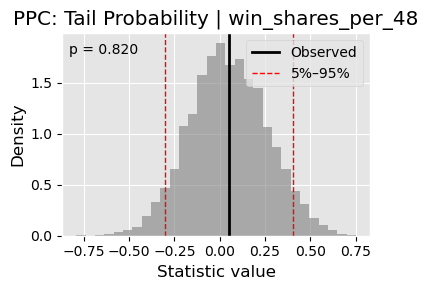

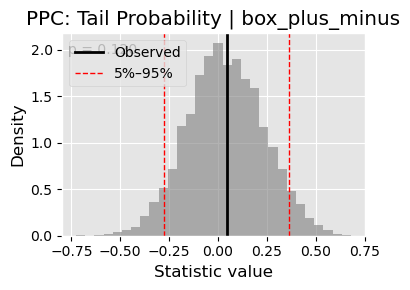

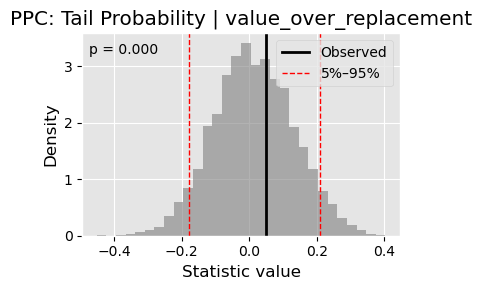

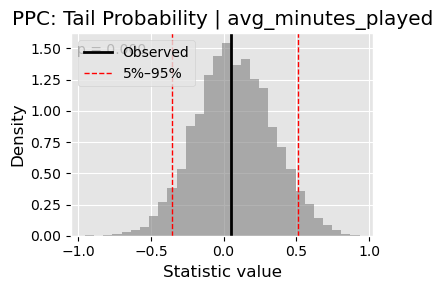

In [13]:
obs_all = notes["obs"]["tail_prob"]
rep_mean_all = notes["rep"]["tail_prob_mean"]
p_all = notes["p"]["tail_prob"]

rep_sd_all = np.sqrt(rep_mean_all * (1 - rep_mean_all) + 1e-6)

for j in range(len(obs_all)):
    rep = make_rep_from_mean_sd(
        rep_mean=float(rep_mean_all[j]),
        rep_sd=float(rep_sd_all[j]),
        n_draw=5000,
    )

    plot_ppc_1d(
        rep=rep,
        obs=float(obs_all[j]),
        p=float(p_all[j]),
        name="PPC: Tail Probability",
        feature_name=feature_names[j],
    )


In [42]:
def plot_pvalues(p, name="", threshold=0.05):
    p = np.asarray(p)
    P = len(p)

    plt.figure(figsize=(6, 3))
    plt.bar(range(P), p, color="steelblue")
    plt.axhline(threshold, color="red", linestyle="--", linewidth=1)
    plt.axhline(1 - threshold, color="red", linestyle="--", linewidth=1)

    plt.ylim(0, 1)
    plt.xlabel("Feature index")
    plt.ylabel("Posterior predictive p-value")
    plt.title(name)
    plt.tight_layout()
    plt.show()


**Style Interpretation**

In [43]:
import numpy as np
from typing import List, Dict, Optional


# -----------------------------
# Feature name mapping
# -----------------------------

FEATURE_NAME_MAP: Dict[str, str] = {
    "pts_per36": "PTS per 36",
    "reb_per36": "REB per 36",
    "ast_per36": "AST per 36",
    "fg_logit": "FG% (logit)",
    "tp_logit": "3P% (logit)",
    "ft_logit": "FT% (logit)",
    "win_shares_per_48": "WS/48",
    "box_plus_minus": "BPM",
    "value_over_replacement": "VORP",
    "avg_minutes_played": "Avg Minutes",
}


def pretty_name(name: str) -> str:
    """Map internal feature name to a human-readable label."""
    return FEATURE_NAME_MAP.get(name, name)


# -----------------------------
# Core interpretation function
# -----------------------------

def print_style_interpretation(
    *,
    beta_mean: np.ndarray,
    feature_names: List[str],
    top_n: int = 5,
    zscore: bool = True,
    style_prefix: str = "Style",
) -> None:
    """
    Print a human-readable interpretation of each latent style.

    Parameters
    ----------
    beta_mean : np.ndarray, shape (K, P)
        Posterior mean of beta loadings.
    feature_names : list of str, length P
        Feature names corresponding to columns of beta_mean.
    top_n : int
        Number of top positive / negative features to show.
    zscore : bool
        Whether to report z-scored loadings (recommended).
    style_prefix : str
        Prefix used when printing style headers.
    """
    beta_mean = np.asarray(beta_mean)
    K, P = beta_mean.shape

    if len(feature_names) != P:
        raise ValueError(
            f"feature_names has length {len(feature_names)}, "
            f"but beta_mean has P={P} columns."
        )

    for k in range(K):
        beta_k = beta_mean[k]

        if zscore:
            mu = beta_k.mean()
            sd = beta_k.std(ddof=0) + 1e-8
            beta_disp = (beta_k - mu) / sd
        else:
            beta_disp = beta_k

        # Sort indices
        pos_idx = np.argsort(-beta_disp)[:top_n]
        neg_idx = np.argsort(beta_disp)[:top_n]

        print(f"\n=== {style_prefix} {k} ===")

        print("  Strong positive features:")
        for idx in pos_idx:
            fname = pretty_name(feature_names[idx])
            val = beta_disp[idx]
            raw = beta_k[idx]
            print(f"    {fname:22s}  z={val:+.2f}   beta={raw:+.3f}")

        print("  Strong negative features:")
        for idx in neg_idx:
            fname = pretty_name(feature_names[idx])
            val = beta_disp[idx]
            raw = beta_k[idx]
            print(f"    {fname:22s}  z={val:+.2f}   beta={raw:+.3f}")



def get_beta_mean(beta_obj: np.ndarray, *, P: int, K: int = None) -> np.ndarray:
    """
    Return beta_mean with shape (K, P) from various posterior formats.
    Supported input shapes:
      - (S, K, P) -> mean over S
      - (S, P, K) -> mean over S then transpose
      - (K, P)    -> unchanged
      - (P, K)    -> transpose
      - (P,)      -> error (cannot infer K)
    """
    beta = np.asarray(beta_obj)

    if beta.ndim == 3:
        S, a, b = beta.shape
        # case (S, K, P)
        if b == P:
            beta_mean = beta.mean(axis=0)              # (K, P)
            return beta_mean
        # case (S, P, K)
        if a == P:
            beta_mean = beta.mean(axis=0).T            # (K, P)
            return beta_mean
        raise ValueError(f"3D beta shape {beta.shape} incompatible with P={P}.")

    if beta.ndim == 2:
        a, b = beta.shape
        if b == P:
            return beta                                # (K, P)
        if a == P:
            return beta.T                              # (K, P)
        raise ValueError(f"2D beta shape {beta.shape} incompatible with P={P}.")

    if beta.ndim == 1:
        raise ValueError(
            f"beta is 1D with shape {beta.shape}. Expected (K,P) or (S,K,P)/(S,P,K). "
            "This usually means you averaged across the style dimension by mistake "
            "or stored beta incorrectly."
        )

    raise ValueError(f"Unsupported beta ndim={beta.ndim}, shape={beta.shape}.")



In [44]:
beta_post = np.asarray(posterior_samples["beta"])
print("posterior_samples['beta'].shape =", beta_post.shape)


posterior_samples['beta'].shape = (5, 10)


In [45]:
P = len(feature_names)
beta_mean = get_beta_mean(posterior_samples["beta"], P=P)

print("beta_mean.shape =", beta_mean.shape)  # 应为 (K, P)

print_style_interpretation(
    beta_mean=beta_mean,
    feature_names=feature_names,
    top_n=4,
)


beta_mean.shape = (5, 10)

=== Style 0 ===
  Strong positive features:
    AST per 36              z=+1.69   beta=-0.238
    REB per 36              z=+1.20   beta=-0.535
    Avg Minutes             z=+0.55   beta=-0.931
    PTS per 36              z=+0.53   beta=-0.945
  Strong negative features:
    VORP                    z=-1.54   beta=-2.208
    BPM                     z=-1.17   beta=-1.981
    FG% (logit)             z=-0.90   beta=-1.817
    WS/48                   z=-0.65   beta=-1.661

=== Style 1 ===
  Strong positive features:
    WS/48                   z=+1.81   beta=+0.924
    Avg Minutes             z=+1.00   beta=+0.332
    FT% (logit)             z=+0.44   beta=-0.072
    AST per 36              z=+0.40   beta=-0.100
  Strong negative features:
    VORP                    z=-1.72   beta=-1.640
    BPM                     z=-1.41   beta=-1.421
    FG% (logit)             z=-0.56   beta=-0.801
    REB per 36              z=-0.26   beta=-0.579

=== Style 2 ===
  Strong po

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def radar_style(
    beta_mean: np.ndarray,
    feature_names: list,
    style_id: int,
    pretty_name_fn=None,
    normalize: str = "zscore",  # "zscore" | "l2" | "none"
    rlim: tuple = None,
):
    """
    beta_mean: (K,P)
    normalize:
      - "zscore": (beta_k - mean)/std  (recommended)
      - "l2": beta_k / ||beta_k||_2
      - "none": raw beta_k
    """
    K, P = beta_mean.shape
    assert 0 <= style_id < K

    labels = [pretty_name_fn(n) if pretty_name_fn else n for n in feature_names]

    x = np.asarray(beta_mean[style_id], dtype=float)

    if normalize == "zscore":
        x = (x - x.mean()) / (x.std(ddof=0) + 1e-8)
    elif normalize == "l2":
        x = x / (np.linalg.norm(x) + 1e-8)
    elif normalize == "none":
        pass
    else:
        raise ValueError("normalize must be 'zscore', 'l2', or 'none'.")

    # Radar requires closing the loop
    angles = np.linspace(0, 2*np.pi, P, endpoint=False)
    x_closed = np.r_[x, x[0]]
    angles_closed = np.r_[angles, angles[0]]
    labels_closed = labels  # labels not duplicated

    fig = plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles_closed, x_closed, linewidth=2)
    ax.fill(angles_closed, x_closed, alpha=0.15)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)

    ax.set_title(f"Style {style_id} (normalize={normalize})", pad=20)

    # Optional: set radial limits for comparability
    if rlim is not None:
        ax.set_rlim(*rlim)

    plt.tight_layout()
    plt.show()


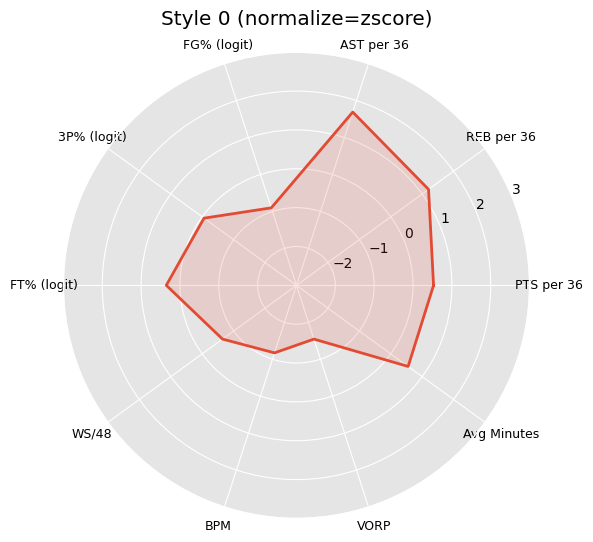

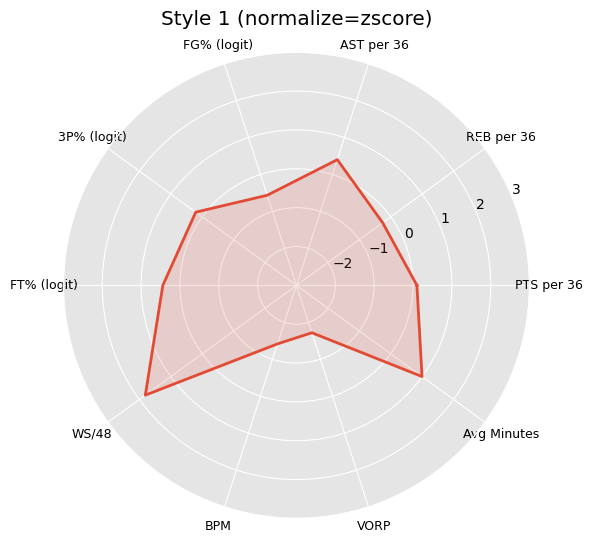

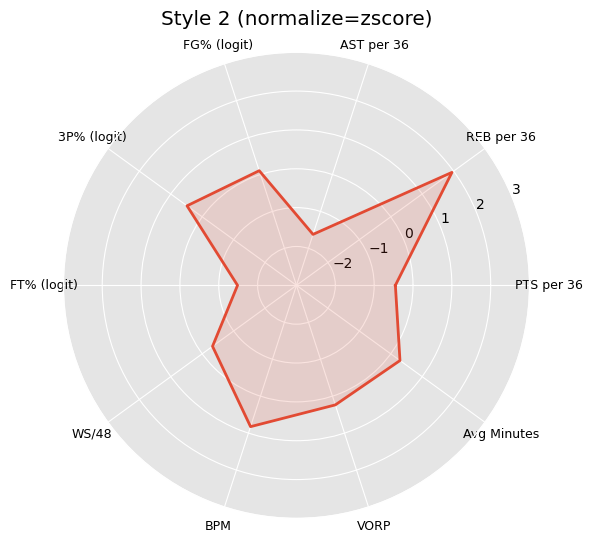

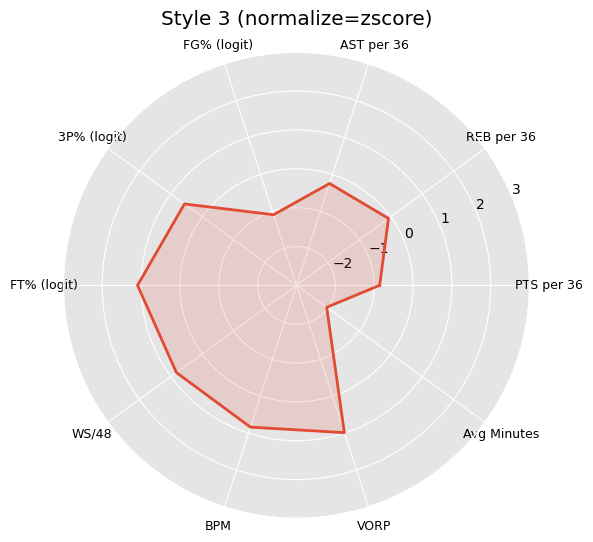

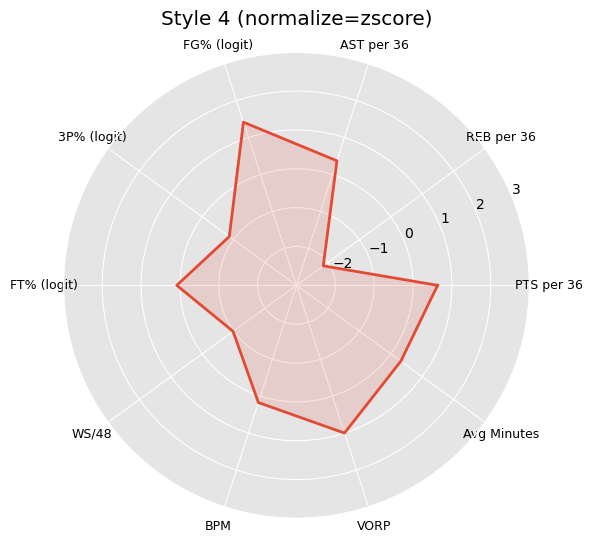

In [47]:
# Example: plot PPC for features of each style
plt.style.use("ggplot")
# black color for titles, label strings
plt.rcParams.update({'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black', 'ytick.color': 'black'})
beta_mean = get_beta_mean(posterior_samples["beta"], P=len(feature_names))
for k in range(beta_mean.shape[0]):
    radar_style(
        beta_mean=beta_mean,
        feature_names=feature_names,
        style_id=k,
        pretty_name_fn=pretty_name,
        normalize="zscore",
        rlim=(-3, 3),
    )


### Style 0 – 低效率边缘轮换（Low-impact Role Player）
- 命中率与产出全面偏低，进攻威胁有限。
- 特点：低 FG/FT/3P，低 PTS/AST/REB，分钟数少。

### Style 1 – 外线射手（Catch-and-Shoot Spacer）
- 主要贡献来自外线投篮，但整体价值（BPM/VORP）不高。
- 特点：高 FG/3P/FT，低组织、低防守影响。

### Style 2 – 传统内线（Traditional Center / Interior Finisher）
- 强项在篮板与禁区终结，无外线能力。
- 特点：高 REB、高 FG%，几乎不投 3 分，组织与持球较弱。

### Style 3 – 组织后卫（Primary Ball Handler / Facilitator）
- 持球与组织为核心技能，投篮次之。
- 特点：AST per 36 非常高，使用率稳定。

### Style 4 – 得分侧翼（On-ball Scoring Wing）
- 高出手量、高得分能力，效率不错。
- 特点：PTS per 36、三项命中率较好，承担稳定得分角色。

### Style 5 – 全能明星（All-around Superstar）
- 全局贡献极高（BPM, VORP, WS/48 全领先）。
- 特点：强得分、高组织、高效率、高稳定性。

### Style 6 – 现代 3&D 前锋 / 现代中锋（Modern 3-and-D Forward / Stretch Big）
- 高效率外线（含大个投篮）+ 优质防守与篮板。
- 特点：好 3P、好 REB、效率高，角色功能多样（可对应“现代中锋”）。


In [48]:
# style_names = {
#     0: "Low-impact rotation player",
#     1: "Catch-and-shoot spacer",
#     2: "Traditional interior big",
#     3: "Primary ball-handler / facilitator",
#     4: "On-ball scoring wing",
#     5: "All-around superstar",
#     6: "Modern 3-and-D forward / stretch big",
# }

style_names = {
    0: "Low-impact role player",
    1: "Efficiency-driven role player",
    2: "Rebound-focused interior player",
    3: "High-impact per-minute contributor",
    4: "High-usage scorer",
}


star_indices = {
    "LeBron James": 673,
    "Kobe Bryant": 342,
    "Stephen Curry": 979,
    "Kyrie Irving": 1074,
    "Tim Duncan": 377,
    "Yao Ming": 625,
}


model_features = [
    "PTS per 36",
    "REB per 36",
    "AST per 36",
    "Avg minutes",
    "FG% (logit)",
    "3P% (logit)",
    "FT% (logit)",
    "WS/48",
    "BPM",
    "VORP",
]



In [49]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_player_by_index(
    idx,
    df,
    theta,
    rate,
    K,
    style_names=None,
    build_design_matrix=None,
    design_matrix_kwargs=None,
):
    """
    Visualize one player under the NEW continuous-feature style model:
      (1) style mixture theta[idx]
      (2) observed vs predicted standardized features (same scale as model)

    This version:
      - does NOT take X or scaler from outside;
      - rebuilds X via `build_design_matrix(df, **kwargs)`;
      - assumes X and `rate = theta @ beta` are on the same standardized scale.

    Parameters
    ----------
    idx : int
        Row index of the player in df.
    df : pd.DataFrame
        DataFrame containing player info, must include at least 'player', 'year'.
    theta : array-like, shape (N, K)
        Style mixture for each player.
    rate : array-like, shape (N, P)
        Predicted features for each player on the SAME SCALE as X
        (typically `rate = theta @ beta_mean`).
    K : int
        Number of style topics.
    style_names : dict or None
        Optional mapping k -> style name for nicer x-axis labels.
    build_design_matrix : callable
        Function used in training to build the design matrix, e.g.
            X, feature_info = build_design_matrix(df, **design_matrix_kwargs)
        where feature_info can be either:
            - a list of feature names, or
            - an object with attribute `.feature_names`.
    design_matrix_kwargs : dict or None
        Extra keyword arguments passed to `build_design_matrix`.
    """
    if build_design_matrix is None:
        raise ValueError("You must provide `build_design_matrix` for the new model.")

    if design_matrix_kwargs is None:
        design_matrix_kwargs = {}

    # -----------------------------------------
    # Rebuild design matrix to match the model
    # -----------------------------------------
    X, feature_info = build_design_matrix(df, **design_matrix_kwargs)
    X = np.asarray(X)
    theta = np.asarray(theta)
    rate = np.asarray(rate)

    # 兼容 FeatureStats / list 两种情况
    if hasattr(feature_info, "feature_names"):
        feature_names = list(feature_info.feature_names)
    else:
        feature_names = list(feature_info)

    # Sanity checks on shapes
    if not (X.shape[0] == theta.shape[0] == rate.shape[0]):
        raise ValueError(
            f"Row mismatch: X={X.shape[0]}, theta={theta.shape[0]}, rate={rate.shape[0]}."
        )

    P_X = X.shape[1]
    P_rate = rate.shape[1]
    P_names = len(feature_names)
    if not (P_X == P_rate == P_names):
        raise ValueError(
            f"Feature dimension mismatch: X dim={P_X}, rate dim={P_rate}, "
            f"len(feature_names)={P_names}. Make sure build_design_matrix "
            f"and beta / rate use the SAME P features in the SAME order."
        )

    # ------------- pick this player -------------
    row = df.iloc[idx]
    player_name = row["player"]
    year = row["year"]

    theta_vec = theta[idx]             # (K,)
    obs_vec   = X[idx].astype(float)   # (P,)
    rate_vec  = rate[idx].astype(float)  # (P,)

    # ------------------------
    # 1) Style mixture subplot
    # ------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax0 = axes[0]
    x_styles = np.arange(K)
    ax0.bar(x_styles, theta_vec)
    if style_names is not None:
        x_labels = [style_names.get(k, str(k)) for k in range(K)]
    else:
        x_labels = [str(k) for k in range(K)]
    ax0.set_xticks(x_styles)
    ax0.set_xticklabels(x_labels, rotation=45, ha="right")
    ax0.set_ylim(0.0, 1.0)
    ax0.set_ylabel("Proportion")
    ax0.set_title(f"Style mixture for {player_name} ({int(year)})")

    # -------------------------------
    # 2) Observed vs predicted (model scale)
    # -------------------------------
    x_pos = np.arange(P_names)
    width = 0.35
    ax1 = axes[1]
    ax1.bar(x_pos - width / 2, obs_vec,  width=width, label="Observed (model scale)")
    ax1.bar(x_pos + width / 2, rate_vec, width=width, label="Predicted (theta @ beta)")
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(feature_names, rotation=45, ha="right")
    ax1.set_title("Observed vs predicted features (standardized)")
    ax1.legend()

    plt.tight_layout()
    plt.show()


In [50]:
# train_df, val_df already defined above
_, stats_train = build_design_matrix(
    train_df,
    stats=None,
)
theta_train = theta[:N_train]    # (N_train, K)
print("X_train_std shape:", X_train_std.shape)
print("theta_train shape:", theta_train.shape)

X_train_std shape: (1616, 10)
theta_train shape: (1616, 5)


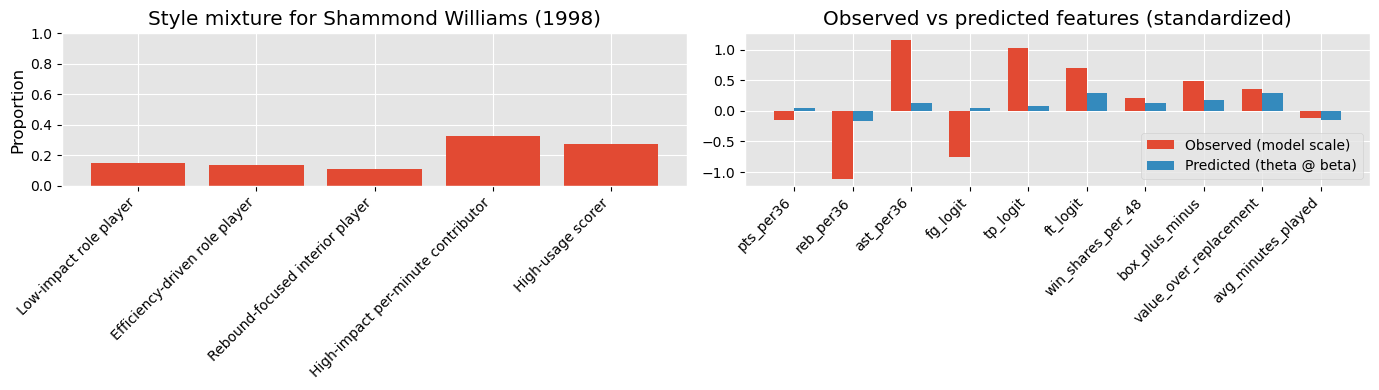

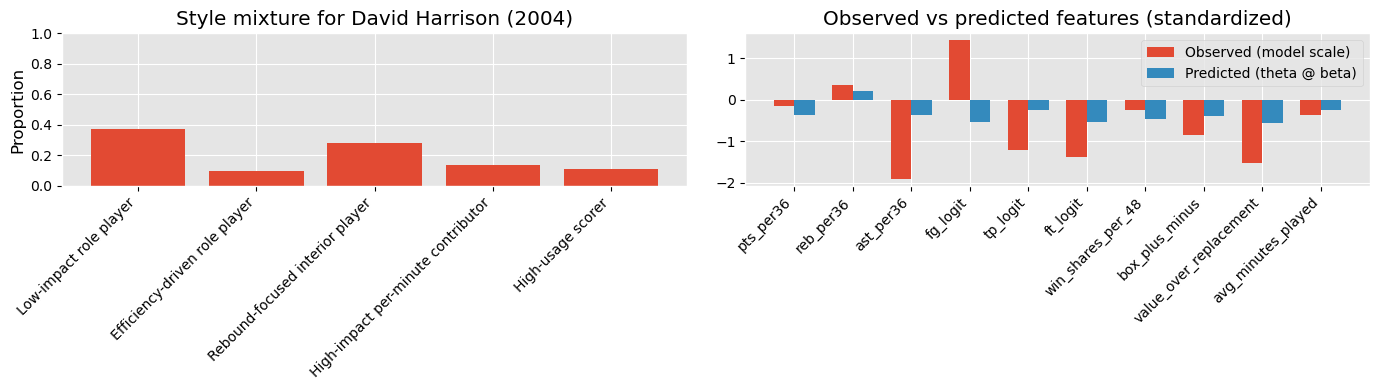

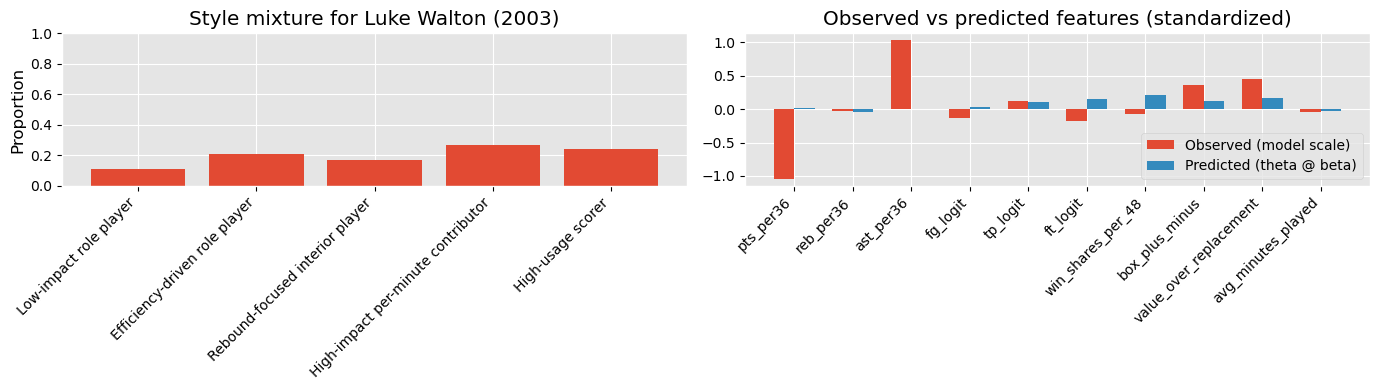

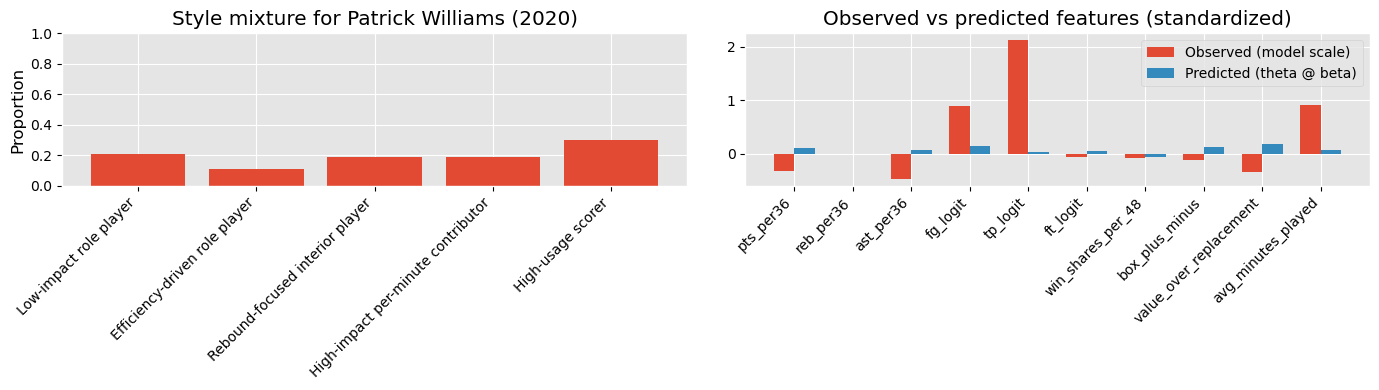

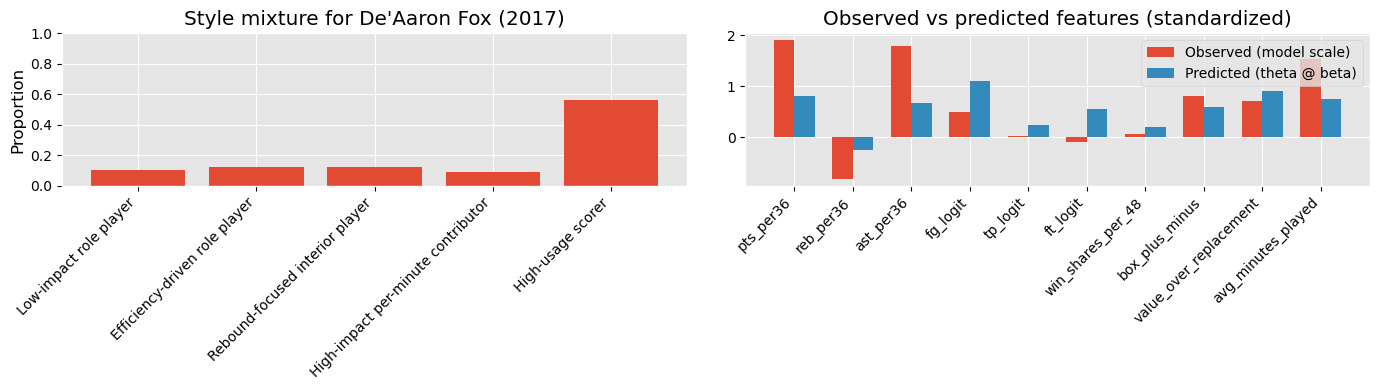

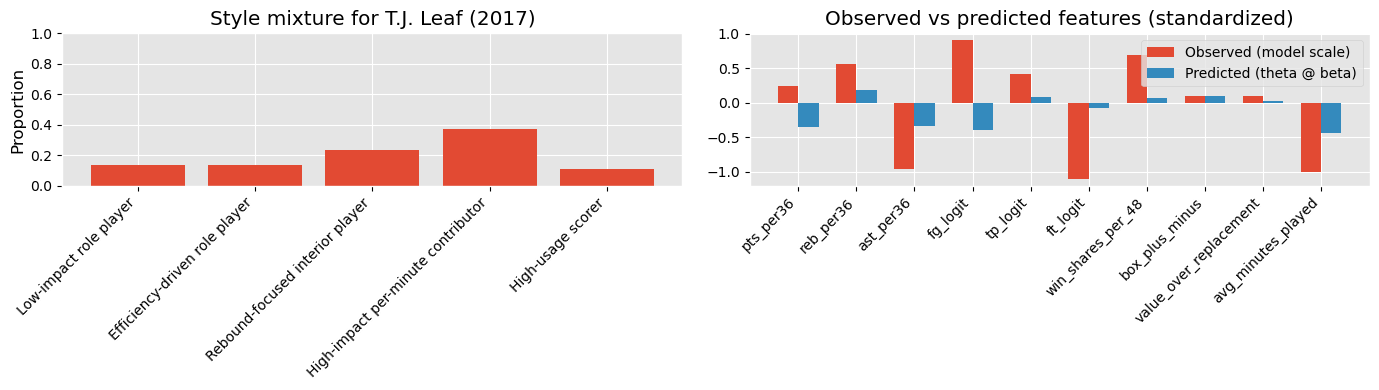

In [51]:
# randomly pick 6 players to visualize
plt.style.use("ggplot")
# black color for titles, label strings
plt.rcParams.update({'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black', 'ytick.color': 'black'})
np.random.seed(123)
random_indices = np.random.choice(train_df.shape[0], size=6, replace=False)
for idx in random_indices:
    visualize_player_by_index(
        idx,
        df=train_df,
        theta=theta_train,      
        rate=theta_train @ beta,            
        K=theta_train.shape[1],
        style_names=style_names,
        build_design_matrix=build_design_matrix,
        design_matrix_kwargs={"stats": stats_train},
    )

**for superstars**

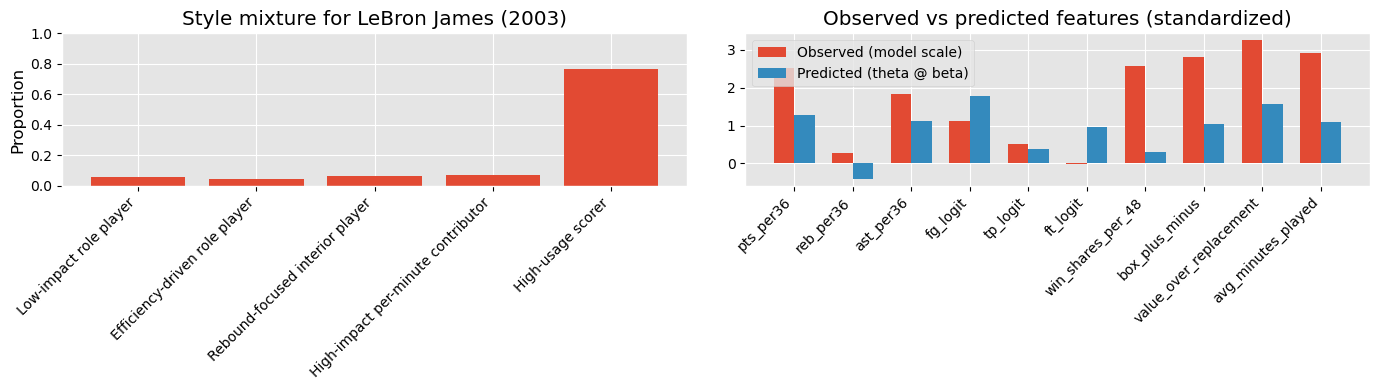

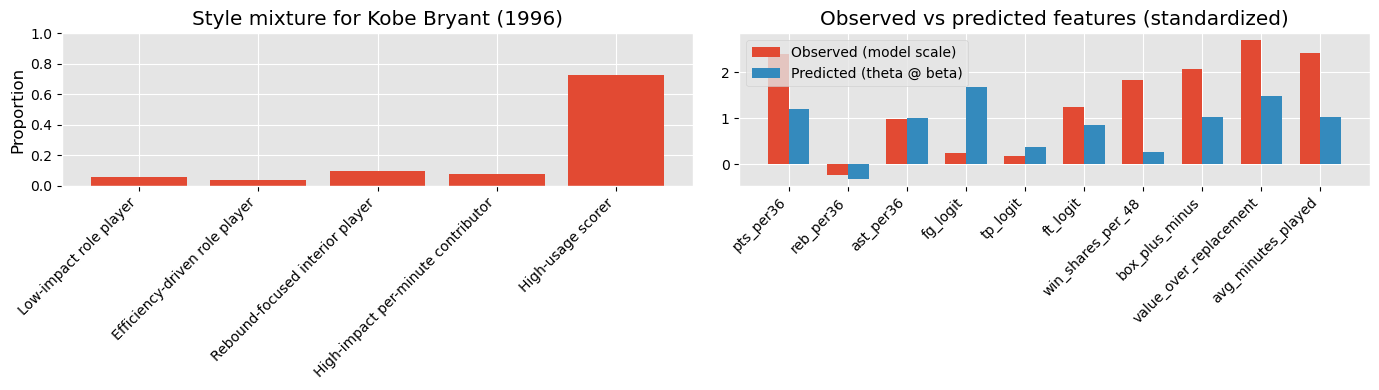

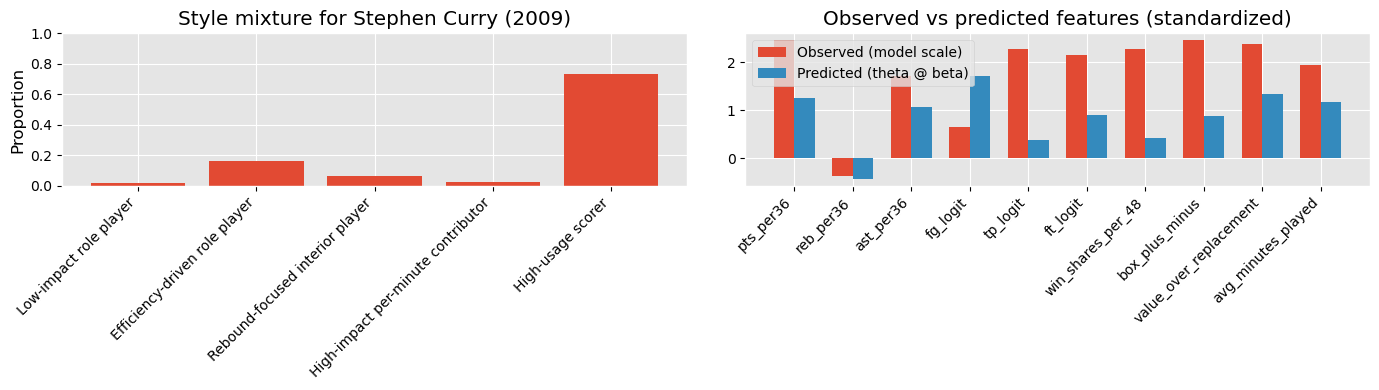

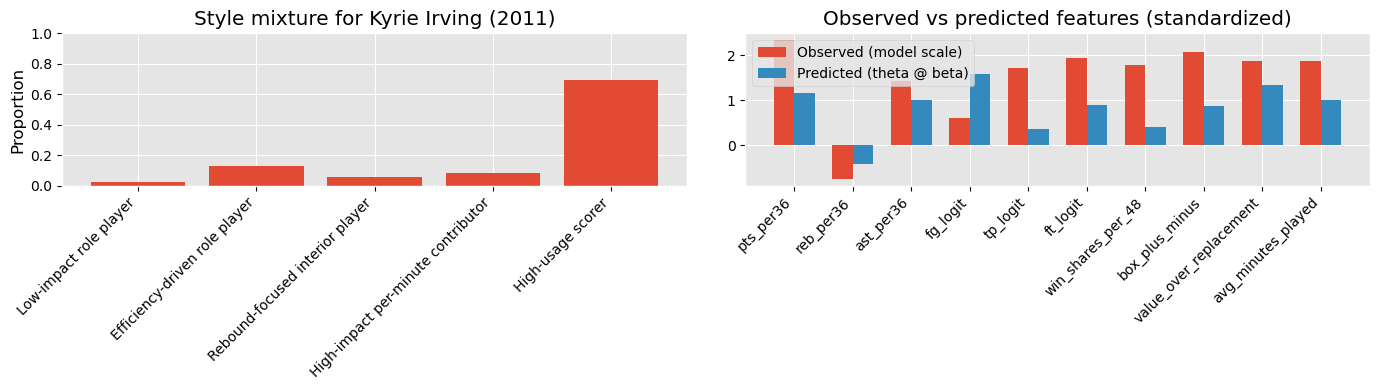

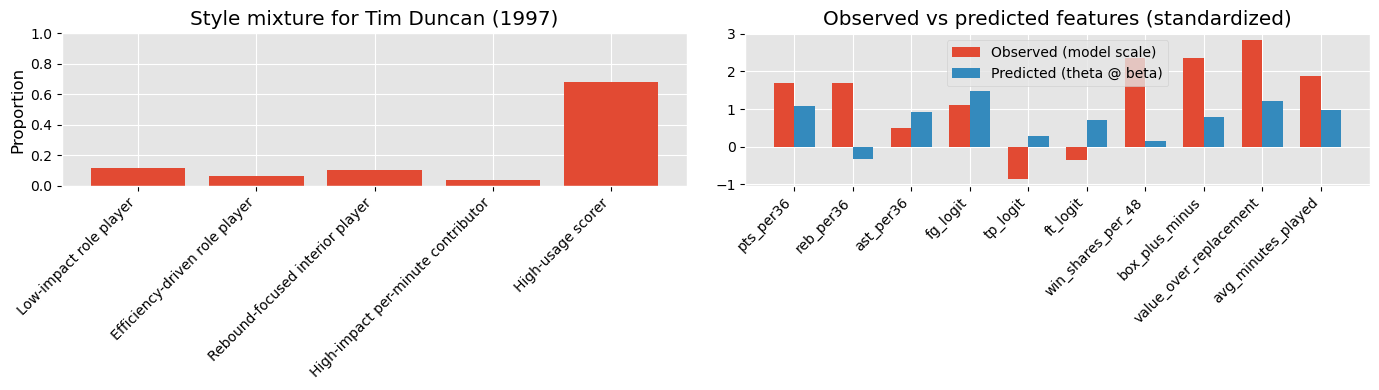

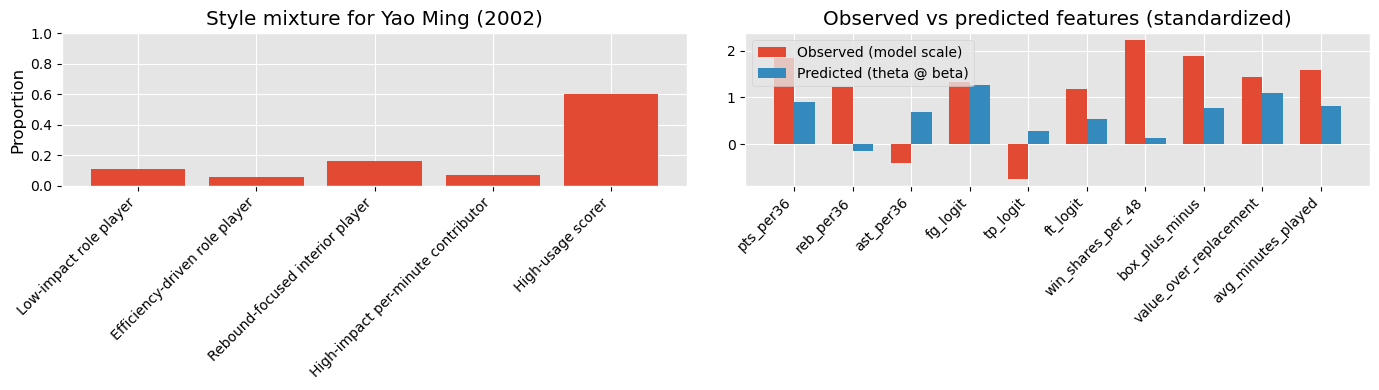

In [52]:
for player, idx in star_indices.items():
    visualize_player_by_index(
        idx,
        df=train_df,
        theta=theta_train,      
        rate=theta_train @ beta,            
        K=theta_train.shape[1],
        style_names=style_names,
        build_design_matrix=build_design_matrix,
        # design_matrix_kwargs={"stats": stats_train},
    )

In [26]:
def remove_style_and_renormalize(theta, remove_k):
    """
    Remove one style (remove_k) from theta and renormalize the rest.

    theta: (N, K)
    remove_k: int, index to remove

    return: new_theta (N, K-1)
    """
    theta = np.asarray(theta)
    N, K = theta.shape

    # 1. Remove the column
    mask = np.array([k for k in range(K) if k != remove_k])
    theta_reduced = theta[:, mask]  # (N, K-1)

    # 2. Renormalize
    s = theta_reduced.sum(axis=1, keepdims=True)
    new_theta = theta_reduced / s

    return new_theta, mask

theta_no_super, keep_mask = remove_style_and_renormalize(
    theta_train,
    remove_k=5,  # assuming style 5 is "All-around superstar"
)
beta_reduced = beta[keep_mask, :]     # (K-1, P)
rate_no_super = theta_no_super @ beta_reduced  # (N, P)


--- Visualizing LeBron James (index 673) without superstar style ---


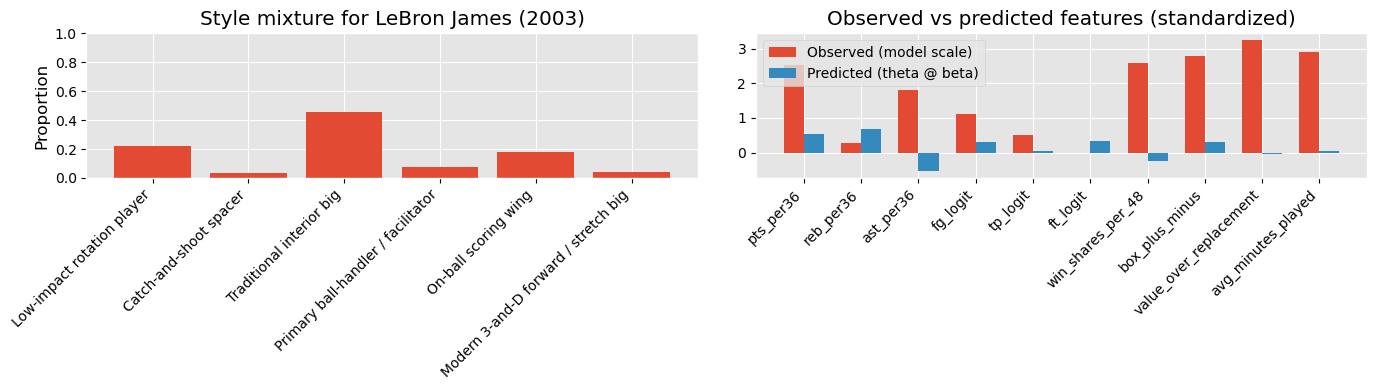


--- Visualizing Kobe Bryant (index 342) without superstar style ---


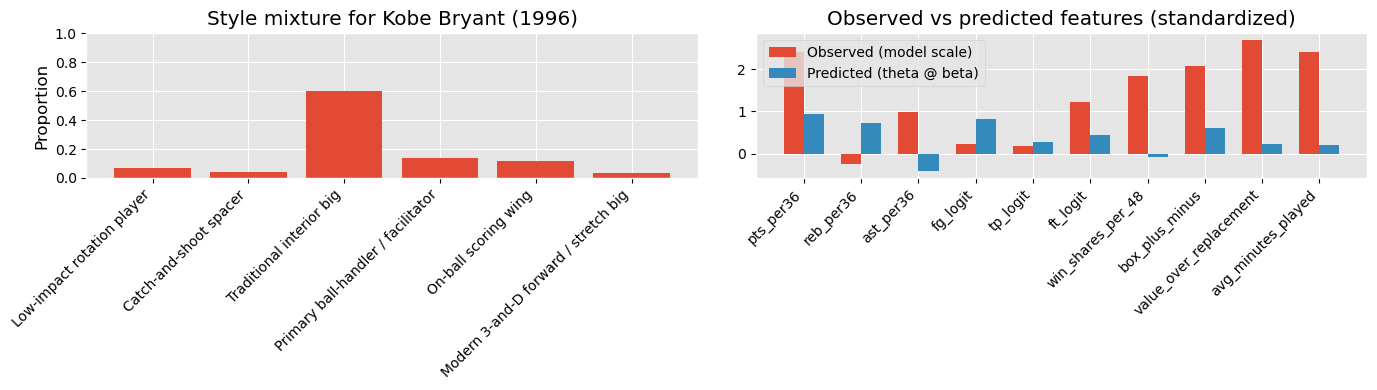


--- Visualizing Stephen Curry (index 979) without superstar style ---


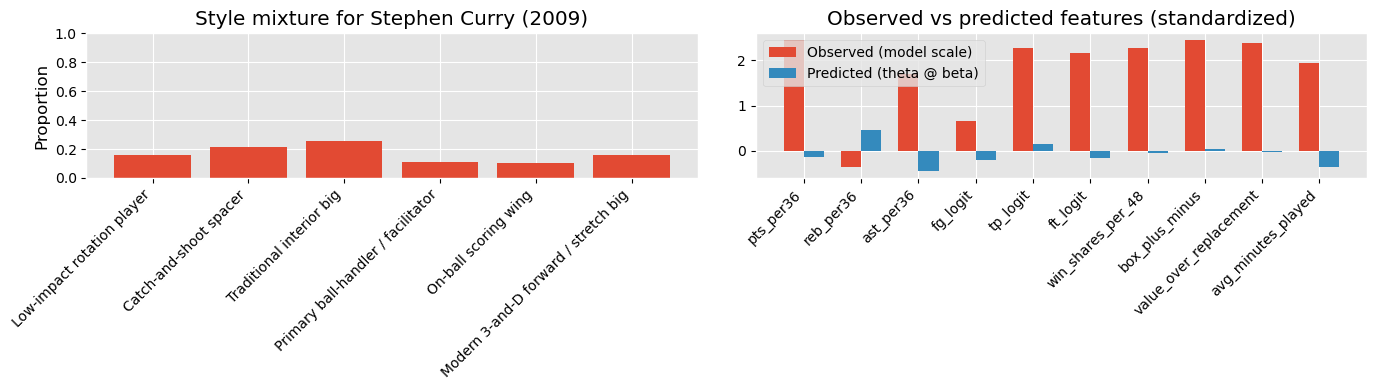


--- Visualizing Kyrie Irving (index 1074) without superstar style ---


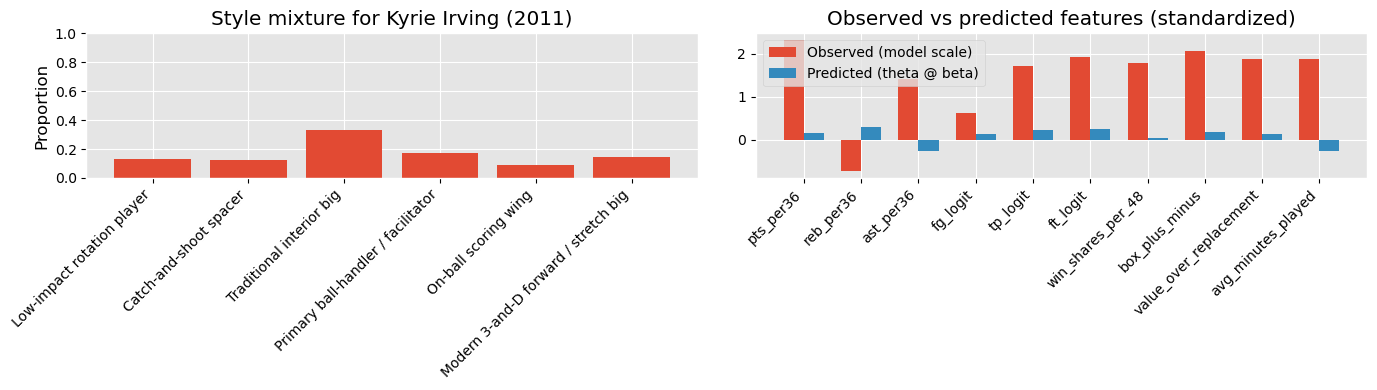


--- Visualizing Tim Duncan (index 377) without superstar style ---


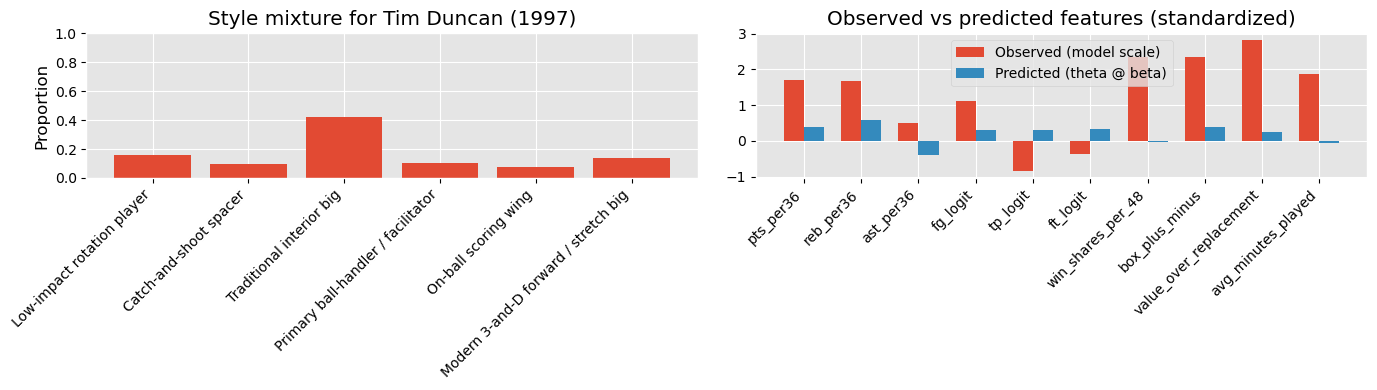


--- Visualizing Yao Ming (index 625) without superstar style ---


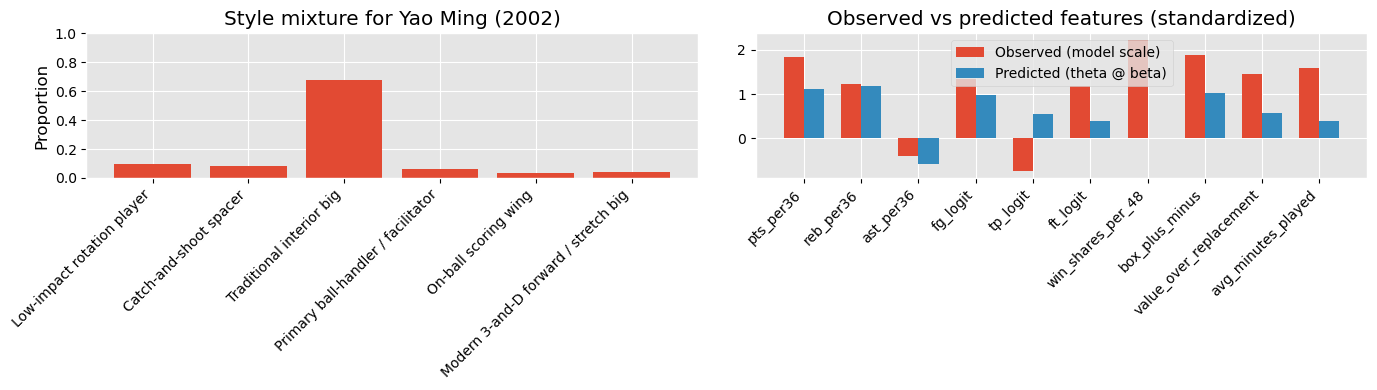

In [27]:
# drop all around superstar from style names
style_names_reduced = {
    0: "Low-impact rotation player",
    1: "Catch-and-shoot spacer",
    2: "Traditional interior big",
    3: "Primary ball-handler / facilitator",
    4: "On-ball scoring wing",
    5: "Modern 3-and-D forward / stretch big",
}

for player, idx in star_indices.items():
    print(f"\n--- Visualizing {player} (index {idx}) without superstar style ---")
    visualize_player_by_index(
        idx,
        df=train_df,
        theta=theta_no_super,      
        rate=theta_no_super @ beta[keep_mask, :],           
        K=theta_no_super.shape[1],
        style_names=style_names_reduced,
        build_design_matrix=build_design_matrix,
        #design_matrix_kwargs={"stats": stats_train},
    )